# Análise Exploratória de Dados (EDA) — Segurança Pública no Brasil

Nesta etapa, será realizada a análise exploratória dos indicadores de segurança pública, buscando identificar padrões, diferenças entre as Unidades da Federação e variações entre os anos de 2023 e 2024.

In [1]:
# Importando as bibliotecas utilizadas na análise
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Carregando a base consolidada
dados = pd.read_csv(
    '../data/processed/dados_consolidados.csv'
)

# Carregando a base de proporção de feminicídios
proporcao_feminicidios = pd.read_csv(
    '../data/processed/proporcao_feminicidios.csv'
)

In [3]:
# Exibindo os primeiros registros da base principal
dados.head()

,uf,ano,indicador,ocorrencias,taxa_100_mil
0,Brasil,2023,MVI,46441,21.937677
1,Acre,2023,MVI,214,24.413004
2,Alagoas,2023,MVI,1210,37.593903
3,Amapá,2023,MVI,519,64.946116
4,Amazonas,2023,MVI,1406,33.155912


## Visão geral dos dados

Inicialmente, será realizada uma análise geral da base consolidada para verificar sua dimensão, estrutura, tipos de dados e indicadores disponíveis.

In [4]:
# Verificando a quantidade de linhas e colunas
dados.shape

(448, 5)

In [5]:
# Verificando os tipos de dados das colunas
dados.dtypes

uf                  str
ano               int64
indicador           str
ocorrencias       int64
taxa_100_mil    float64
dtype: object

In [6]:
# Exibindo os indicadores disponíveis na base
dados['indicador'].unique()

<StringArray>
[                       'MVI',       'Latrocínio - vítimas',
   'Latrocínio - ocorrências',         'Roubo de celulares',
         'Furto de celulares', 'Roubo e furto de celulares',
     'Homicídios de mulheres',               'Feminicídios']
Length: 8, dtype: str

In [7]:
# Exibindo os anos disponíveis na base
dados['ano'].unique()

array([2023, 2024])

In [8]:
# Contando os registros por indicador e ano
dados.groupby(
    ['indicador', 'ano']
).size()

indicador                   ano 
Feminicídios                2023    28
                            2024    28
Furto de celulares          2023    28
                            2024    28
Homicídios de mulheres      2023    28
                            2024    28
Latrocínio - ocorrências    2023    28
                            2024    28
Latrocínio - vítimas        2023    28
                            2024    28
MVI                         2023    28
                            2024    28
Roubo de celulares          2023    28
                            2024    28
Roubo e furto de celulares  2023    28
                            2024    28
dtype: int64

## Análise das Mortes Violentas Intencionais (MVI)

Nesta etapa, são analisadas as Mortes Violentas Intencionais (MVI), comparando os anos de 2023 e 2024 e identificando as Unidades da Federação com as maiores taxas por 100 mil habitantes.

In [9]:
# Filtrando apenas os registros de MVI
mvi = dados[
    dados['indicador'] == 'MVI'
].copy()

# Exibindo os primeiros registros
mvi.head()

,uf,ano,indicador,ocorrencias,taxa_100_mil
0,Brasil,2023,MVI,46441,21.937677
1,Acre,2023,MVI,214,24.413004
2,Alagoas,2023,MVI,1210,37.593903
3,Amapá,2023,MVI,519,64.946116
4,Amazonas,2023,MVI,1406,33.155912


In [10]:
# Verificando a quantidade de registros de MVI
mvi.shape

(56, 5)

In [11]:
# Filtrando os dados de MVI de 2024 e removendo o Brasil
mvi_2024 = mvi[
    (mvi['ano'] == 2024) &
    (mvi['uf'] != 'Brasil')
].copy()

# Ordenando os estados pela maior taxa de MVI
ranking_mvi_2024 = mvi_2024.sort_values(
    'taxa_100_mil',
    ascending=False
)

# Exibindo os 10 estados com as maiores taxas
ranking_mvi_2024[
    ['uf', 'ocorrencias', 'taxa_100_mil']
].head(10)

,uf,ocorrencias,taxa_100_mil
31,Amapá,362,45.090099
33,Bahia,6036,40.645061
34,Ceará,3467,37.547424
45,Pernambuco,3453,36.198653
30,Alagoas,1141,35.433638
38,Maranhão,2129,30.366740
39,Mato Grosso,1142,29.767498
42,Pará,2560,29.546510
32,Amazonas,1173,27.398803
50,Rondônia,455,26.056177


In [12]:
# Exibindo os 10 estados com as maiores taxas (Ajustado para 2 casas decimais)
ranking_mvi_2024[
    ['uf', 'ocorrencias', 'taxa_100_mil']
].head(10).round(2)

,uf,ocorrencias,taxa_100_mil
31,Amapá,362,45.09
33,Bahia,6036,40.65
34,Ceará,3467,37.55
45,Pernambuco,3453,36.20
30,Alagoas,1141,35.43
38,Maranhão,2129,30.37
39,Mato Grosso,1142,29.77
42,Pará,2560,29.55
32,Amazonas,1173,27.40
50,Rondônia,455,26.06


### Estados com as maiores taxas de MVI em 2024

A análise a seguir apresenta as Unidades da Federação com as maiores taxas de Mortes Violentas Intencionais (MVI) por 100 mil habitantes em 2024.

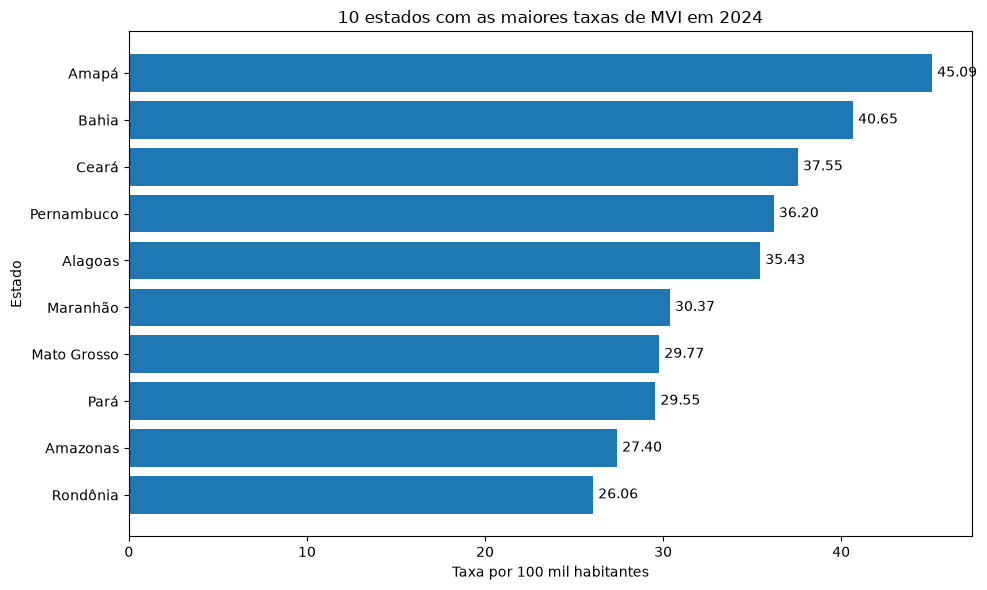

In [13]:
# Selecionando os 10 estados com as maiores taxas de MVI
top10_mvi_2024 = ranking_mvi_2024.head(10)

# Cria o gráfico de barras
plt.figure(figsize=(10, 6))

plt.barh(
    top10_mvi_2024['uf'],
    top10_mvi_2024['taxa_100_mil']
)

# Adiciona os valores das taxas nas barras
for indice, valor in enumerate(top10_mvi_2024['taxa_100_mil']):
    plt.text(
        valor + 0.3,
        indice,
        f'{valor:.2f}',
        va='center'
    )
    
# Adiciona título e nomes dos eixos
plt.title('10 estados com as maiores taxas de MVI em 2024')
plt.xlabel('Taxa por 100 mil habitantes')
plt.ylabel('Estado')

# Coloca a maior taxa no topo
plt.gca().invert_yaxis()

# Ajusta o layout
plt.tight_layout()

# Exibe o gráfico
plt.show()

### Insight

Em 2024, o Amapá apresentou a maior taxa de Mortes Violentas Intencionais (MVI) entre todos os estados analisados, com aproximadamente 45,09 ocorrências por 100 mil habitantes.

Bahia, Ceará, Pernambuco e Alagoas aparecem logo em seguida como os estados com as maiores taxas. Esse resultado mostra que a análise proporcional à população pode destacar estados que não necessariamente possuem os maiores números absolutos de ocorrências.

### Variação da taxa de Mortes Violentas Intencionais (MVI) entre 2023 e 2024

A análise a seguir compara as taxas de Mortes Violentas Intencionais (MVI) entre 2023 e 2024, buscando identificar as Unidades da Federação que apresentaram os maiores aumentos e reduções no período.

In [14]:
# Removendo o Brasil da comparação entre os estados
mvi_estados = mvi[
    mvi['uf'] != 'Brasil'
].copy()

# Organizando as taxas de 2023 e 2024 em colunas separadas
comparacao_mvi = mvi_estados.pivot(
    index='uf',
    columns='ano',
    values='taxa_100_mil'
).reset_index()

# Renomeando as colunas
comparacao_mvi.columns = [
    'uf',
    'taxa_2023',
    'taxa_2024'
]

# Exibindo os primeiros registros
comparacao_mvi.head()

,uf,taxa_2023,taxa_2024
0,Acre,24.413004,20.326334
1,Alagoas,37.593903,35.433638
2,Amapá,64.946116,45.090099
3,Amazonas,33.155912,27.398803
4,Bahia,44.366350,40.645061


In [15]:
# Calculando a variação percentual da taxa de MVI entre 2023 e 2024
comparacao_mvi['variacao_percentual'] = (
    (comparacao_mvi['taxa_2024'] - comparacao_mvi['taxa_2023'])
    / comparacao_mvi['taxa_2023']
) * 100

# Exibe os registros
comparacao_mvi.head()

,uf,taxa_2023,taxa_2024,variacao_percentual
0,Acre,24.413004,20.326334,-16.739726
1,Alagoas,37.593903,35.433638,-5.746317
2,Amapá,64.946116,45.090099,-30.573063
3,Amazonas,33.155912,27.398803,-17.363750
4,Bahia,44.366350,40.645061,-8.387640


In [16]:
# Ordenando os estados pela maior variação percentual
maiores_aumentos = comparacao_mvi.sort_values(
    'variacao_percentual',
    ascending=False
)

# Os 5 estados com os maiores aumentos
maiores_aumentos[
    ['uf', 'taxa_2023', 'taxa_2024', 'variacao_percentual']
].head(5).round(2)

,uf,taxa_2023,taxa_2024,variacao_percentual
9,Maranhão,27.09,30.37,12.11
5,Ceará,33.86,37.55,10.89
25,São Paulo,7.59,8.16,7.50
12,Minas Gerais,14.35,15.07,5.00
23,Santa Catarina,8.50,8.50,-0.02


In [17]:
# Ordenado os estados pela maior redução na taxa de MVI
maiores_reducoes = comparacao_mvi.sort_values(
    'variacao_percentual',
    ascending=True
)

# Os 5 estados com as maiores reduções
maiores_reducoes[
    ['uf', 'taxa_2023', 'taxa_2024', 'variacao_percentual']
].head(5).round(2)

,uf,taxa_2023,taxa_2024,variacao_percentual
2,Amapá,64.95,45.09,-30.57
26,Tocantins,27.44,19.78,-27.91
22,Roraima,25.46,18.55,-27.12
24,Sergipe,30.19,22.78,-24.54
18,Rio Grande do Norte,30.32,24.17,-20.28


In [18]:
# Ordenando os estados pela maior variação positiva na taxa de MVI
maiores_aumentos = comparacao_mvi.sort_values(
    'variacao_percentual',
    ascending=False
)

# Os 5 estados com os maiores aumentos
maiores_aumentos[
    ['uf', 'taxa_2023', 'taxa_2024', 'variacao_percentual']
].head(5).round(2)

,uf,taxa_2023,taxa_2024,variacao_percentual
9,Maranhão,27.09,30.37,12.11
5,Ceará,33.86,37.55,10.89
25,São Paulo,7.59,8.16,7.50
12,Minas Gerais,14.35,15.07,5.00
23,Santa Catarina,8.50,8.50,-0.02
